#Download data

In [1]:
#to get the data
!pip install yfinance
!pip install lxml
!pip install keras tensorflow
!pip install torch
!pip install requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 14.0 MB/s eta 0:00:00 MB/s eta 0:00:01:01
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 25.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 20.3 MB/s eta 0:00:0031m19.2 MB/s eta 0:00:01
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)


In [25]:

import pandas as pd
import seaborn as sns
import numpy as np
import yfinance as yf
import requests
from io import StringIO
import math
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import keras
import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time
import itertools
import tensorflow as tf
print("done")

done


In [26]:
# get labels from wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
html = requests.get(url, headers=headers, timeout=20)
html.raise_for_status()
sp500_df = pd.read_html(StringIO(html.text))[0]
tickers = sp500_df["Symbol"].str.replace(".", "-", regex=False).tolist() # for some reason there are 503 labels, figure out why!!!

# I think it is better to ignore the index
# tickers.insert(0,'^GSPC') # add S&P500 index, which we try to predict

# Download all S&P 500 data given the previous labels
data = yf.download(tickers=tickers,start="2015-01-01",end="2023-01-01",group_by='ticker',threads=True)

# just keep opening prices
open_prices = pd.concat({ticker: data[ticker]["Close"] for ticker in data.columns.levels[0]},axis=1)

# remove firms with nan-values, remove around 50 firms
open_prices_interp = open_prices.interpolate(method='linear', axis=0, limit=1) # if nan-values at one point then average between before and after, for instance, if uneven opening days for some reason
open_prices_interp = open_prices_interp.dropna(axis=1) # this should drop columns containing nan-values

# remove firms without sector or industry information for graphs, only removes 1 firm
tickers_with_data = list(open_prices_interp.columns)
firm_industry_dict = {}
removed_labels = []

sector_map   = dict(zip(sp500_df["Symbol"].str.replace(".", "-", regex=False), sp500_df["GICS Sector"]))
industry_map = dict(zip(sp500_df["Symbol"].str.replace(".", "-", regex=False), sp500_df["GICS Sub-Industry"]))

firm_industry_dict = {}
removed_labels = []

for firm in tickers_with_data:
    if firm in sector_map and firm in industry_map:
        firm_industry_dict[firm] = (sector_map[firm], industry_map[firm])
    else:
        removed_labels.append(firm)

tickers_with_data = [f for f in tickers_with_data if f not in removed_labels]
open_prices_interp = open_prices_interp.drop(columns=removed_labels)

# remove firms without graph data
open_prices_interp = open_prices_interp.drop(columns=removed_labels)

# into numpy
x = open_prices_interp.to_numpy() 

/var/folders/zw/q9ynbccn7ps6lh79162xl0j80000gn/T/ipykernel_87026/2311101026.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers=tickers,start="2015-01-01",end="2023-01-01",group_by='ticker',threads=True)
[*********************100%***********************]  503 of 503 completed

7 Failed downloads:
['SNDK', 'GEV', 'Q', 'KVUE', 'SOLV', 'VLTO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2023-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1672549200")')
['CPAY']: Timeout('Failed to perform, curl: (28) Operation timed out after 10001 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


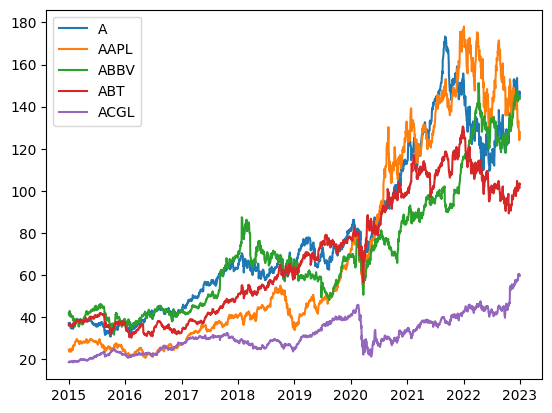

In [27]:
# just to get a visualization that it looks right
for i in open_prices_interp.columns[:5]:
  prices = open_prices_interp[i]
  plt.plot(prices.index, prices.values, label=f'{i}')
plt.legend()

In [28]:
# what do we do with those companies not on the stock exchange the entire time? Nan values, like the one below?
# I have dropped companies that contained nan values, because they were annoying. I think these companies that later joined the S&P500 and were not not a part of the stock exchange at that time
#open_prices['ABNB']

In [29]:
sum(np.isnan(x))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

(461, 461)


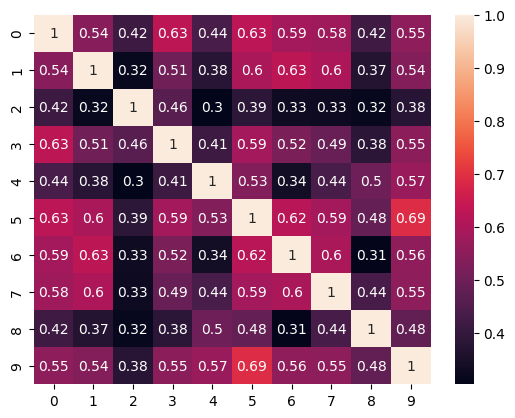

In [30]:
# Make data more stationary by using log and diff, so we get the relative changes  (I thought that an LSTM model could predict non-stationary time-series, but it was a bit tough for it)
x_returns = np.diff(np.log(x),axis=0)

# calculate the correlation
corr_ = np.corrcoef(x_returns.T)
ax = sns.heatmap(corr_[:10,:10], annot=True)
print(corr_.shape)

In [31]:
set_of_sector = set()
set_of_industry = set()
for val in firm_industry_dict.values():
  sector, industry = val
  set_of_sector.add(sector)
  set_of_industry.add(industry)

# make adjacency matrix
firm_tickers = tickers_with_data # I have removed  '^GSPC', so no difference now
N = len(firm_tickers)
A = np.zeros((N, N, 3)) # 2 types of relation, industry and sector

for i, ti in enumerate(firm_tickers):
    for j, tj in enumerate(firm_tickers):
        if ti == tj:
            continue
        if firm_industry_dict[ti][1] == firm_industry_dict[tj][1]:
            A[i, j, 0] = 1   # connection type 1
        elif firm_industry_dict[ti][0] == firm_industry_dict[tj][0]:
            A[i, j, 1] = 1   # connection type 2
# add the correlation matrix to adjacency matrix
A[:,:,2] = corr_  # this correlation is on the entire period, perhaps just do it for training period

# RQ1
## Prepare data for LSTM

In [32]:
# create moving average features, what they do in the paper
windows = [5, 10, 20, 30]

def moving_average(a, window):
    return np.apply_along_axis(lambda x: np.convolve(x, np.ones(window)/window, mode='valid'), axis=0, arr=a)

ma_dict = {w: moving_average(x_returns, w) for w in windows}
min_T = min(ma.shape[0] for ma in ma_dict.values())
x_trim = x_returns[-min_T:]
ma_trimmed = [ma_dict[w][-min_T:] for w in windows]
features = np.stack([x_trim] + ma_trimmed, axis=-1)

f'(Time point, firm, type of price)= {features.shape}'

'(Time point, firm, type of price)= (1984, 461, 5)'

## Create training, validation and test data

In [33]:
def create_data(batch_size=32, flatten_data = True, shuffle_train= True):
  # target all prices at time t
  target = features[:, :, 0]

  # split up the data
  n = len(target)
  train_end = n // 2
  val_end = train_end + n // 4
  train_raw = features[:train_end,:,:]
  val_raw   = features[train_end:val_end,:,:]
  test_raw  = features[val_end:,:, :]

  # Get original shapes for reshaping back
  train_shape = train_raw.shape
  val_shape = val_raw.shape
  test_shape = test_raw.shape

  # Reshape 3D data to 2D for StandardScaler (combine first two dimensions)
  train_reshaped = train_raw.reshape(-1, train_shape[-1])
  val_reshaped = val_raw.reshape(-1, val_shape[-1])
  test_reshaped = test_raw.reshape(-1, test_shape[-1])
  sc = StandardScaler()
  train_scaled_reshaped = sc.fit_transform(train_reshaped)
  val_scaled_reshaped   = sc.transform(val_reshaped)
  test_scaled_reshaped  = sc.transform(test_reshaped)

  # Reshape back to 3D after scaling
  train_scaled = train_scaled_reshaped.reshape(train_shape)
  val_scaled   = val_scaled_reshaped.reshape(val_shape)
  test_scaled  = test_scaled_reshaped.reshape(test_shape)

  # Concatenate along the time dimension (axis=0)
  full_scaled = np.concatenate((train_scaled, val_scaled, test_scaled), axis=0)

  seq_len = 8
  X, y = [], []
  for i in range(seq_len, len(full_scaled)):
      X.append(full_scaled[i-seq_len:i, :,:])
      y.append(full_scaled[i, :, 0])

  X = np.array(X, dtype=np.float32)
  y = np.array(y, dtype=np.float32)

  train_idx = train_end - seq_len
  val_idx   = val_end - seq_len

  X_train, y_train = X[:train_idx], y[:train_idx]
  X_val,   y_val   = X[train_idx:val_idx], y[train_idx:val_idx]
  X_test,  y_test  = X[val_idx:], y[val_idx:]

  # keras can max input 3D and not 4D
  if flatten_data:
    (T, L, N, F) = X_train.shape
    X_train = X_train.reshape(T,L,N*F)
    (T, L, N, F) = X_val.shape
    X_val = X_val.reshape(T,L,N*F)
    (T, L, N, F) = X_test.shape
    X_test = X_test.reshape(T,L,N*F)


  # Convert to torch tensors and make into mini-batches (otherwise it can crash as it uses too much RAM)
  X_train_t = torch.tensor(X_train, dtype=torch.float32)
  X_val_t   = torch.tensor(X_val, dtype=torch.float32)
  X_test_t  = torch.tensor(X_test, dtype=torch.float32)

  y_train_t = torch.tensor(y_train, dtype=torch.float32)
  y_val_t   = torch.tensor(y_val, dtype=torch.float32)
  y_test_t  = torch.tensor(y_test, dtype=torch.float32)

  print(X_train_t.shape)  # (T_train, 8, 460, 5)
  print(y_train_t.shape)  # (T_train, 460)

  train_ds = TensorDataset(X_train_t, y_train_t)
  val_ds   = TensorDataset(X_val_t, y_val_t)
  test_ds  = TensorDataset(X_test_t, y_test_t)

  train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_train) # this includes all the data makes it into batches
  val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
  test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
  return X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader

batch_size =32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(batch_size =batch_size)


torch.Size([984, 8, 2305])
torch.Size([984, 461])


## the LSTM model

In [16]:
for x,y in train_loader:
  print(x.shape, y.shape)
  break

torch.Size([32, 8, 2310]) torch.Size([32, 462])


### [new] Nat's attempt

Trying to adjust Mathias's LSTM model to put it into functions and iterate over it with different parameters

In [17]:
### Set Parameters
param_grid = {
    'lstm_units': [64, 128, 256],
    'dropout_rate': [0.2, 0.3, 0.5],
    # 'batch_size': [64, 128, 256],
    'learning_rate': [0.0005, 0.001],
    'patience': [10],
    'epochs': [30]
}

In [18]:
### Convert PyTorch format to be compatible with tf/keras
def dataloader_to_numpy(dataloader):
    X_list, y_list = [], []
    for X_batch, y_batch in dataloader:
        X_list.append(X_batch.numpy())
        y_list.append(y_batch.numpy())
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_train, y_train = dataloader_to_numpy(train_loader)
X_val,   y_val   = dataloader_to_numpy(val_loader)

In [19]:
### Function to build and compile the model
def build_compile_lstm_model(hidden_units, input_size, output_size, dropout_rate, learning_rate):

    model = Sequential()

    model.add(LSTM(units=hidden_units, return_sequences=True))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=hidden_units*2, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(units=output_size))
    model.build(input_shape=input_size) # This fixes "unbuilt", so we can see number of parameters in each layer. Nothing else

    # Optimizer
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    # opt = optim.Adam(model.parameters(), lr=learning_rate)

    # Metrics
    metric = ['accuracy'] # create shape ratio above? !!! , f1_score, matthews_corrcoef>

    # Compile model
    model.compile(optimizer = opt, loss = 'mean_squared_error', metrics=metric) # use mean_squared_error when regression problem

    return model

In [20]:
### Function to train the model
def train_model(model, train_data, validation_data, epochs=30, patience=10):

    X_train, y_train = train_data
    X_val,   y_val   = validation_data

    best_val_loss = 100.0
    best_weights = None
    patience_counter = 0
    history_metrics = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):

        # Training step
        history_es = model.fit(X_train, y_train, epochs=1, shuffle=False, verbose=0)

        epoch_loss = history_es.history['loss'][0]
        epoch_acc = history_es.history['accuracy'][0]

        # Validation step
        val_results = model.evaluate(X_val, y_val, verbose=0)
        val_loss = val_results[0]
        val_acc = val_results[1]

        history_metrics['train_loss'].append(epoch_loss)
        history_metrics['train_acc'].append(epoch_acc)
        history_metrics['val_loss'].append(val_loss)
        history_metrics['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")

        # Patience
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.get_weights()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Restore best weights
    model.set_weights(best_weights)
    return model, history_metrics, best_val_loss

In [21]:
best_overall_loss, best_config, best_model_final, best_history_final = 100.0, {}, None, None

results_log = []
grid_search_start_time = time.time()

keys, values = zip(*param_grid.items())
# keys, values = zip(*param_grid_best.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

output_size = y_train.shape[1] # y.shape[1]
input_size = X_train.shape[:]

# configs
MODEL_SAVE_PATH = 'best_lstm_model_graphtheory.keras'

In [22]:
for i, params in enumerate(combinations):
    print(f"\n--- Training Config {i+1}/{len(combinations)}: {params} ---")

    # Build and compile the model
    model = build_compile_lstm_model(
        hidden_units=params['lstm_units'],
        input_size=input_size,
        output_size=output_size,
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    # Training time
    config_train_start_time = time.time()
    trained_model, history_metrics, val_loss = train_model(
        model, train_data=(X_train, y_train), validation_data=(X_val, y_val),
        epochs=params['epochs'], patience=params['patience'])

    config_train_end_time = time.time()
    training_duration = config_train_end_time - config_train_start_time

    # # Inference time on validation
    # inference_start_time = time.time()
    # trained_model.predict(X_val_seq, batch_size=params['batch_size'], verbose=0)
    # inference_end_time = time.time()
    # inference_duration = inference_end_time - inference_start_time

    print(f"Config {i+1} Summary: Val Loss: {val_loss:.4f} | Train Time: {training_duration:.2f}s")
    # print(f"Config {i+1} Summary: Val Loss: {val_loss:.4f} | Train Time: {training_duration:.2f}s | Inference Time: {inference_duration:.2f}s")

    results_log.append({
        'config_id': i + 1,
        'params': str(params),
        'val_loss': val_loss,
        'training_time_s': training_duration
        # 'inference_time_s': inference_duration
    })

    if val_loss < best_overall_loss:
        best_overall_loss = val_loss
        best_config = params
        best_model_final = trained_model
        best_history_final = history_metrics
        print(f"-> New Best Model found!")

grid_search_end_time = time.time()
total_duration = grid_search_end_time - grid_search_start_time

print("\n" + "="*60)
print(f"Grid Search Complete in {total_duration:.2f} seconds.")
print(f"Best Configuration: {best_config} | Best Val loss: {best_overall_loss:.4f}")
best_model_final.save(MODEL_SAVE_PATH)


print("\n--- Detailed Grid Search Results ---")
results_df = pd.DataFrame(results_log)
results_df = results_df.sort_values(by='val_loss', ascending=False)
print(results_df)


--- Training Config 1/18: {'lstm_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'patience': 10, 'epochs': 30} ---
Epoch 1/30 | Train Loss: 1.0089 Acc: 0.0030 | Val Loss: 2.6210 Val Acc: 0.0020
Epoch 2/30 | Train Loss: 0.9993 Acc: 0.0071 | Val Loss: 2.6219 Val Acc: 0.0020
Epoch 3/30 | Train Loss: 0.9900 Acc: 0.0102 | Val Loss: 2.6344 Val Acc: 0.0060
Epoch 4/30 | Train Loss: 0.9741 Acc: 0.0163 | Val Loss: 2.6401 Val Acc: 0.0181
Epoch 5/30 | Train Loss: 0.9598 Acc: 0.0152 | Val Loss: 2.6446 Val Acc: 0.0101
Epoch 6/30 | Train Loss: 0.9410 Acc: 0.0264 | Val Loss: 2.6557 Val Acc: 0.0121
Epoch 7/30 | Train Loss: 0.9259 Acc: 0.0173 | Val Loss: 2.6777 Val Acc: 0.0181
Epoch 8/30 | Train Loss: 0.9038 Acc: 0.0295 | Val Loss: 2.6750 Val Acc: 0.0121
Epoch 9/30 | Train Loss: 0.8896 Acc: 0.0244 | Val Loss: 2.7160 Val Acc: 0.0181
Epoch 10/30 | Train Loss: 0.8637 Acc: 0.0244 | Val Loss: 2.7654 Val Acc: 0.0161
Epoch 11/30 | Train Loss: 0.8447 Acc: 0.0264 | Val Loss: 2.8170 Val Acc: 0.0141
Ear

KeyboardInterrupt: 

### [new] Mathias's code but with altered parameters based on above:

In [36]:
output_dim = y_train.shape[1] # y.shape[1]
# Reduce the number of units significantly as 32*output_dim is too large.
units = 64 # Changed from 32*output_dim to a fixed smaller value, they actually do not specify the units for this one
input_dim = X_train.shape[:]

model = Sequential()
model.add(LSTM(units = units, return_sequences = True))
model.add(Dropout(0.5))
model.add(LSTM(units = units*2, return_sequences = False))
model.add(Dropout(0.5))
model.add(Dense(units = output_dim))
model.build(input_shape=input_dim) # This fixes "unbuilt", so we can see number of parameters in each layer. Nothing else

es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

opt = keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer = opt, loss = 'mean_squared_error')  # use mean_squared_error when regression problem
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_34 (LSTM)                  │ (984, 8, 64)           │       606,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (984, 8, 64)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (984, 128)             │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (984, 128)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (984, 461)             │        59,469 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 765,005 (2.92 MB)

 Trainable params: 765,005 (2.92 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history_es = model.fit(train_loader, epochs=100, validation_data=val_loader, callbacks=[es], shuffle=False) #

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.0120 - val_loss: 2.6205
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0018 - val_loss: 2.6219
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9911 - val_loss: 2.6302
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9852 - val_loss: 2.6311
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9746 - val_loss: 2.6558
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9662 - val_loss: 2.6325
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9588 - val_loss: 2.6661
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9549 - val_loss: 2.6545
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9330 - val_loss: 2.6883
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9360 - val_loss: 2.6720
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9216 - val_loss: 2.6743


In [38]:
pred_scaled = model.predict(X_test[:, :, :])
# Manually inverse transform pred_scaled to undo the scaling
pred = pred_scaled * sc.scale_[0] + sc.mean_[0]
real = y_test * sc.scale_[0] + sc.mean_[0]

max_left_from_ma = max(windows)//2-1
seq_len= 8
start_date_for_plot = 1 + max_left_from_ma + ( seq_len)
dates = open_prices_interp.index[start_date_for_plot : start_date_for_plot + len(y_test)]

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


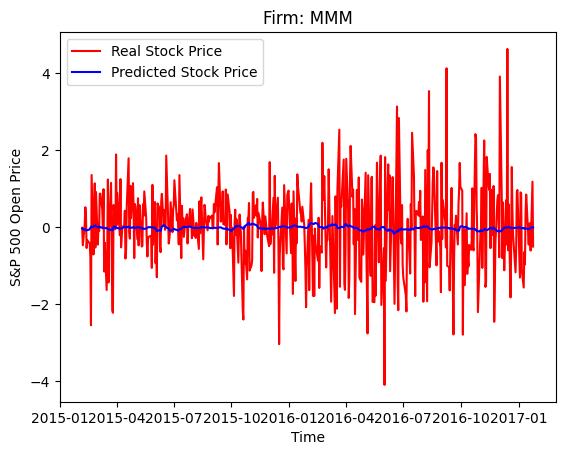

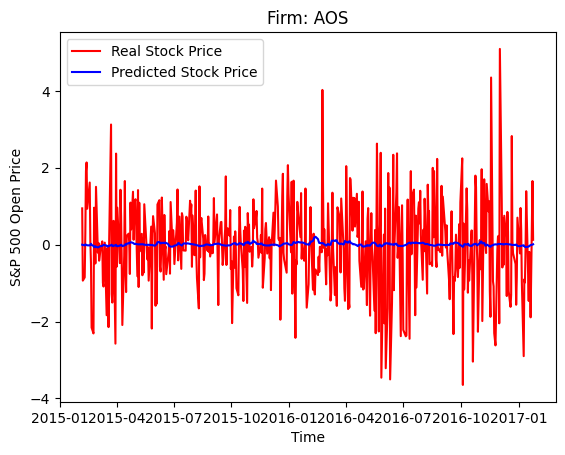

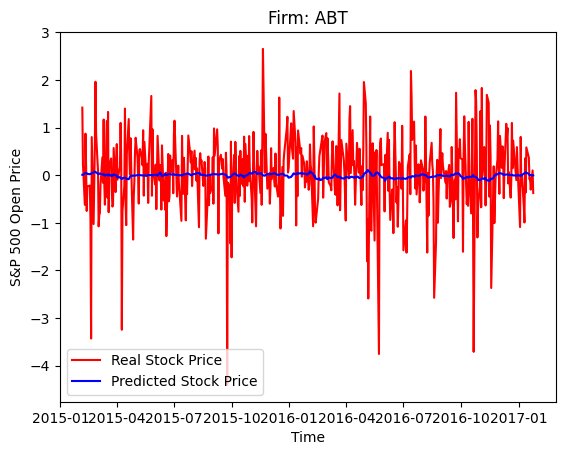

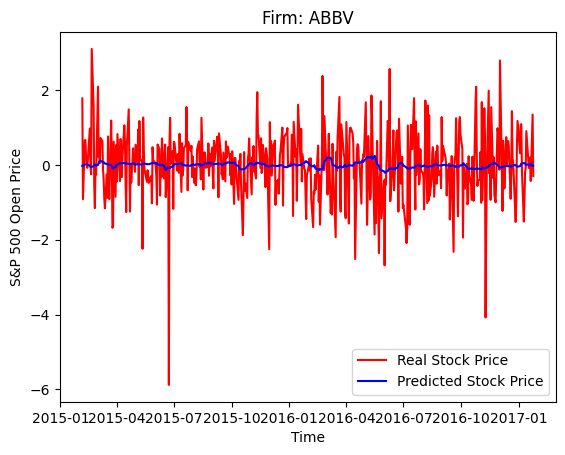

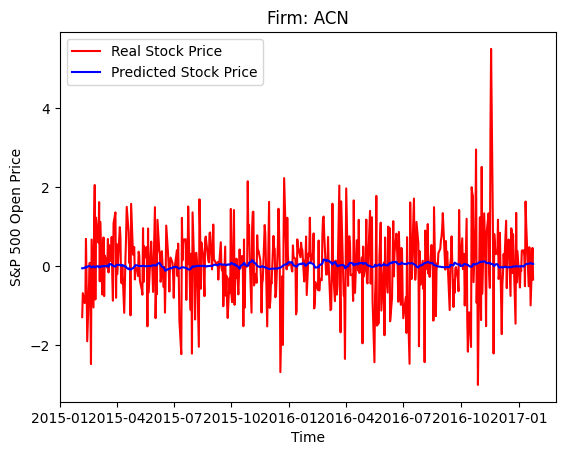

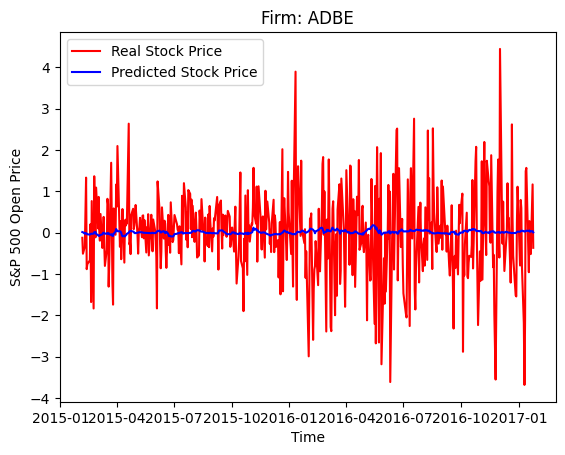

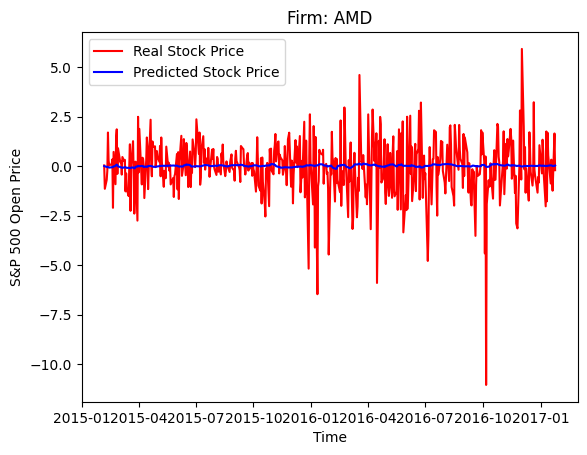

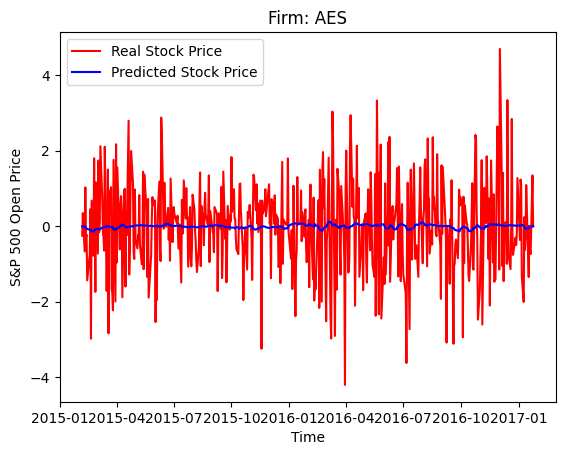

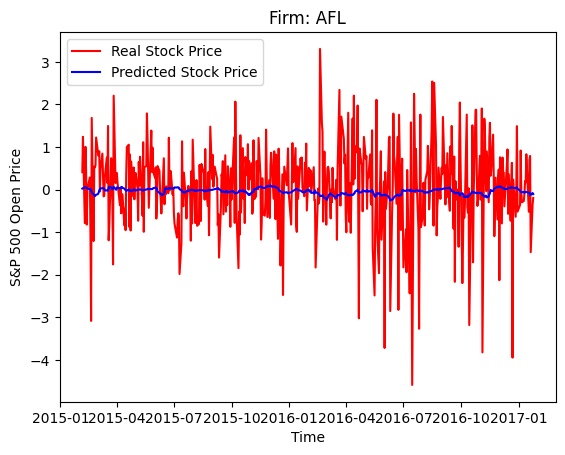

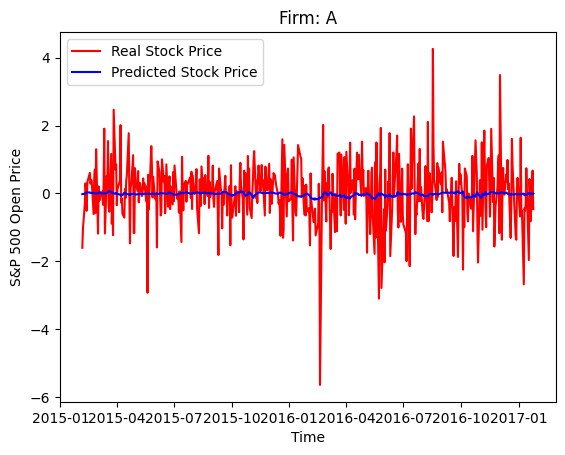

In [39]:
def plot_results(y_test, pred, nr_firms = 10):
  for i in range(nr_firms):
    plt.plot(dates, y_test[:,i], color='red', label='Real Stock Price')
    plt.plot(dates, pred_scaled[:,i], color='blue', label='Predicted Stock Price')
    plt.xlabel('Time')
    plt.ylabel('S&P 500 Open Price')
    plt.title(f"Firm: {tickers[i]}")
    plt.legend()
    plt.show()
plot_results(y_test, pred=pred_scaled) #!!! changed pred to pred_scaled

In [40]:
# It is better to just go with the average hahahh
MSE_array_average = np.mean(((y_test-np.mean(y_train, axis=0)[np.newaxis,:])**2),axis=0)
print(np.mean(MSE_array_average))
MSE_array_LSTM = np.mean((y_test-pred_scaled)**2,axis=0)
print(np.mean(MSE_array_LSTM))
sign_real = y_test>0
sign_pred = pred_scaled>0
print(f'Share for predicting right direction {np.mean((sign_real == sign_pred))}')

1.555662
1.5577607
Share for predicting right direction 0.5002142957105871


In [41]:
print(y_test)

[[-0.01653958  0.9440058   1.4197893  ...  1.138072    0.63659877
  -1.5458314 ]
 [-0.4716199  -0.935372    0.23713246 ... -0.1428547  -0.08964893
  -0.38898718]
 [ 0.06431871 -0.85037905 -0.6205402  ... -0.9503335  -0.42437536
   0.2018457 ]
 ...
 [-0.6095951  -1.8902378  -0.30154157 ... -0.6321554  -1.0234983
  -0.6310658 ]
 [ 1.1814214   1.6536824   0.10058062 ...  0.84818476  2.521129
   1.7533852 ]
 [-0.50619346  0.126587   -0.37275785 ... -0.17628834 -0.28264382
  -0.6724412 ]]


In [42]:
### [new] Metrics to record: accuracy, F1, MCC, Sharpe ratio
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

# Turn into binary/directional
y_test_cat = (y_test > 0).astype(int)
y_pred_scaled_cat = (pred_scaled > 0).astype(int)


# Accuracy
accuracies = [accuracy_score(y_test_cat[:, i], y_pred_scaled_cat[:, i]) for i in range(y_test_cat.shape[1])]
mean_acc = np.mean(accuracies)
print(f"Mean Accuracy: {mean_acc:.4f}")

# F1 - "Macro" F1
f1 = f1_score(y_test_cat, y_pred_scaled_cat, average='macro') # macro treats each label equally
print(f"Macro F1: {f1:.4f}")

# MCC - get per-label MCC then average it
mcc_per_label = [matthews_corrcoef(y_test_cat[:, i], y_pred_scaled_cat[:, i])
                 for i in range(y_test_cat.shape[1])]

mean_mcc = np.mean(mcc_per_label)
print(f"Mean MCC: {mean_mcc:.4f}")


# Sharpe ratio
excess_returns = pred - y_test
avg_excess_return = excess_returns.mean(axis=0)
sd_excess_return = excess_returns.std(axis=0)

daily_sharpe = avg_excess_return / (sd_excess_return + 1e-8)
annual_sharpe = daily_sharpe * np.sqrt(252)

print(f"Mean Sharpe:   {annual_sharpe.mean():.4f}")
print(f"Min Sharpe:    {annual_sharpe.min():.4f}")
print(f"Max Sharpe:    {annual_sharpe.max():.4f}")
print(f"Median Sharpe: {np.median(annual_sharpe):.4f}")


Mean Accuracy: 0.5002
Macro F1: 0.4999
Mean MCC: 0.0006
Mean Sharpe:   0.0992
Min Sharpe:    -1.2309
Max Sharpe:    1.4212
Median Sharpe: 0.1369


### [new2] ARYAA NEW FUNCTION TO COMPUTE METRICS - with sharpe ratio slightly changed 

In [43]:
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

def compute_metrics(y_true, y_pred):
    """
    y_true: numpy array [T, N] — actual returns
    y_pred: numpy array [T, N] — predicted returns
    """

    # Convert to direction labels (1 = up, 0 = down)
    y_true_dir = (y_true > 0).astype(int)
    y_pred_dir = (y_pred > 0).astype(int)

    # Flatten for sklearn
    y_true_flat = y_true_dir.flatten()
    y_pred_flat = y_pred_dir.flatten()

    # Classification metrics
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    f1       = f1_score(y_true_flat, y_pred_flat, average='macro')
    mcc      = matthews_corrcoef(y_true_flat, y_pred_flat)

    # Trading strategy: buy if predicted up, short if predicted down
    trade_sign       = np.where(y_pred_dir == 1, 1, -1)
    strategy_returns = y_true * trade_sign
    daily_returns    = strategy_returns.mean(axis=1)

    # Financial metrics
    return_ratio = daily_returns.sum()
    std          = daily_returns.std()
    sharpe       = (daily_returns.mean() / std) * np.sqrt(252) if std > 0 else 0.0

    return {
        'accuracy':     round(accuracy, 4),
        'f1':           round(f1, 4),
        'mcc':          round(mcc, 4),
        'return_ratio': round(return_ratio, 4),
        'sharpe':       round(sharpe, 4)
    }

# For the LSTM — replacing Nat's cell 29
lstm_metrics = compute_metrics(y_test, pred_scaled)
print(lstm_metrics)

{'accuracy': 0.5002, 'f1': 0.5001, 'mcc': 0.0003, 'return_ratio': np.float64(0.3973), 'sharpe': np.float64(0.0892)}


### Mathias's original code:

In [ ]:
output_dim = y_train.shape[1] # y.shape[1]
# Reduce the number of units significantly as 32*output_dim is too large.
units = 64 # Changed from 32*output_dim to a fixed smaller value, they actually do not specify the units for this one
input_dim = X_train.shape[:]

model = Sequential()
model.add(LSTM(units = units, return_sequences = True))
model.add(Dropout(0.2))
model.add(LSTM(units = units*2, return_sequences = False))
model.add(Dropout(0.2))
model.add(Dense(units = output_dim))
model.build(input_shape=input_dim) # This fixes "unbuilt", so we can see number of parameters in each layer. Nothing else

es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

model.compile(optimizer = 'adam', loss = 'mean_squared_error')  # use mean_squared_error when regression problem
model.summary()

In [ ]:
history_es = model.fit(train_loader, epochs=100, validation_data=val_loader, callbacks=[es], shuffle=False) #

In [ ]:
pred_scaled = model.predict(X_test[:, :, :])
# Manually inverse transform pred_scaled to undo the scaling
pred = pred_scaled * sc.scale_[0] + sc.mean_[0]
real = y_test * sc.scale_[0] + sc.mean_[0]

max_left_from_ma = max(windows)//2-1
seq_len= 8
start_date_for_plot = 1 + max_left_from_ma + ( seq_len)
dates = open_prices_interp.index[start_date_for_plot : start_date_for_plot + len(y_test)]

In [ ]:
def plot_results(y_test, pred, nr_firms = 10):
  for i in range(nr_firms):
    plt.plot(dates, y_test[:,i], color='red', label='Real Stock Price')
    plt.plot(dates, pred_scaled[:,i], color='blue', label='Predicted Stock Price')
    plt.xlabel('Time')
    plt.ylabel('S&P 500 Open Price')
    plt.title(f"Firm: {tickers[i]}")
    plt.legend()
    plt.show()
plot_results(y_test, pred=pred_scaled) #!!! changed pred to pred_scaled

In [ ]:
# It is better to just go with the average hahahh
MSE_array_average = np.mean(((y_test-np.mean(y_train, axis=0)[np.newaxis,:])**2),axis=0)
print(np.mean(MSE_array_average))
MSE_array_LSTM = np.mean((y_test-pred_scaled)**2,axis=0)
print(np.mean(MSE_array_LSTM))
sign_real = y_test>0
sign_pred = pred_scaled>0
print(f'Share for predicting right direction {np.mean((sign_real == sign_pred))}')

# TGC

In [44]:
# The TGC consists of 3 building blocks
# Block 1: The LSTM Encoder
class CompanyEncoder(nn.Module):
    def __init__(self, num_features, emb_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=emb_dim, batch_first=True)

    def forward(self, x):
        # x: [T, L, N, F]
        # Letter for dimensions: T is time periods, L length of sequences, N number of firms, F number of features, B batch size
        B, L, N, F = x.shape

        x = x.permute(0, 2, 1, 3).reshape(B * N, L, F)   # [B*N, L, F]

        _, (h_n, _) = self.lstm(x)
        E = h_n[-1].reshape(B, N, -1)                    # [B, N, emb_dim]
        return E

# Block 2: The Graph Layer
class TemporalMultiRelationGCN(nn.Module):
    def __init__(self, in_dim, out_dim, num_relations):
        super().__init__()
        self.edge_linear = nn.Linear(num_relations, 1)

    def forward(self, E, A):
        # E: [B, N, d]
        # A: [N, N, K]
        # setiup
        B, N, d = E.shape
        E_E = torch.matmul(E, E.transpose(1, 2)) # Same as e_i^T e_j in paper

        edge_score = self.edge_linear(A).squeeze(-1)
        edge_score = torch.relu(edge_score) # this is phi in the paper

        deg = edge_score.sum(dim=0, keepdim=True) + 1e-6
        edge_weight = edge_score / deg                 # phi/d

        weights = E_E * edge_weight.unsqueeze(0)       # Combine: part_1 = e_i^T e_j @ phi/d
        H = torch.matmul(weights, E)                   # combine: part_1@ e_j

        return H

# Block 3: The Dense Layer
# I think I did one extra ReLu/linear layer too much
class Header(nn.Module):
  def __init__(self, gcn_dim):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(gcn_dim, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 1)
    )

  def forward(self, x):
    return self.model(x)

class TGCModel(nn.Module):
    def __init__(self, num_features, emb_dim, gcn_dim, num_relations):
        super().__init__()
        self.encoder = CompanyEncoder(num_features, emb_dim)
        self.tgc = TemporalMultiRelationGCN(emb_dim, gcn_dim, num_relations)
        self.head = Header(gcn_dim)

    def forward(self, x, A):
        # x: [B, L, N, F]
        # A: [N, N, K]
        E = self.encoder(x)               # Embedding layer
        H = self.tgc(E, A)                # combines embeddings and adjacency matrix
        y_hat = self.head(H).squeeze(-1)  # makes N predictions
        return y_hat

In [45]:
batch_size = 32
emb_dim = 32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(batch_size =batch_size, flatten_data=False, shuffle_train=False) # I shuffle for LSTM, perhaps bad, let's figure out
adj_matrix = torch.tensor(A, dtype=torch.float32) # this puts the adjacency matrix into the right format
K = adj_matrix.shape[-1]

torch.Size([984, 8, 461, 5])
torch.Size([984, 461])


In [46]:
# if you guys want to test the things yourself inside TGCModel
# step 0. get a batch and their dimensions
x0, y0 = next(iter(train_loader))
B, L, N, F = x0.shape
# step 1. initialise the encoder and get the embedding matrix, E
encode_model = CompanyEncoder(num_features =F, emb_dim=emb_dim)
E = encode_model(x0) # this does the embedding layer
# step 3. setup the GNN part where we use graph information
gcn_model = TemporalMultiRelationGCN(in_dim=emb_dim, out_dim=emb_dim, num_relations=K)
H_k = gcn_model(E, adj_matrix) #
# step 4. save linear predicter and do the prediction
head = Header(emb_dim)
yhat = head(H_k).squeeze(-1) # shape [B,N]

## Train TGC model

In [47]:
# functions for training, evaluating and predicting
def train_one_epoch(model, loader, A, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        optimizer.zero_grad()

        pred = model(x_batch, A)        # [B, N]
        loss = criterion(pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        total_count += x_batch.size(0)

    return total_loss / total_count

@torch.no_grad()
def evaluate(model, loader, A, criterion):
    model.eval()
    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        pred = model(x_batch, A)
        loss = criterion(pred, y_batch)

        total_loss += loss.item() * x_batch.size(0)
        total_count += x_batch.size(0)

    return total_loss / total_count

@torch.no_grad()
def predict(model, loader, A):
    model.eval()
    preds = []
    ys = []

    for x_batch, y_batch in loader:
        pred = model(x_batch, A)

        preds.append(pred.cpu())
        ys.append(y_batch)

    preds = torch.cat(preds, dim=0)
    return preds

### do the training


In [48]:
# do the training
num_epochs = 20
adj_matrix = torch.tensor(A, dtype=torch.float32)
dict_adj_matrices = {'sector':    {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,0].unsqueeze(-1), 'pred':np.empty},
                     'industry':  {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,1].unsqueeze(-1), 'pred':np.empty},
                     'corre':     {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,2].unsqueeze(-1), 'pred':np.empty},
                     'everything':{'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,:],               'pred':np.empty} }

for key in dict_adj_matrices.keys():
  print(f'Doing model: {key}')
  A_loop = dict_adj_matrices[key]['matrix']
  K_num_relations = A_loop.shape[-1] # This will be 1 for single relations, and 3 for 'everything'

  model_TGC = TGCModel(num_features=F, emb_dim=emb_dim, gcn_dim=emb_dim, num_relations=K_num_relations)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model_TGC.parameters(), lr=1e-3)

  for epoch in range(num_epochs):
      train_loss = train_one_epoch(model_TGC, train_loader, A_loop, optimizer, criterion)
      val_loss = evaluate(model_TGC, val_loader, A_loop, criterion)

      print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
      dict_adj_matrices[key]['model'] = model_TGC
      pred_test_TGC = predict(model_TGC, test_loader, A_loop)
      
      dict_adj_matrices[key]['pred'] = pred_test_TGC
      
      dict_adj_matrices[key]['MSE'] = np.mean((y_test-pred_test_TGC.numpy())**2,axis=0)

      #new2 ARYAA 
      metrics = compute_metrics(y_test, pred_test_TGC.numpy())
      dict_adj_matrices[key]['metrics'] = metrics
      print(f"Metrics for {key}: {metrics}")
   


Doing model: sector
Epoch 01 | train_loss=1.003239 | val_loss=2.640213
Metrics for sector: {'accuracy': 0.5061, 'f1': 0.4594, 'mcc': 0.0099, 'return_ratio': np.float64(1.2565), 'sharpe': np.float64(0.0651)}
Epoch 02 | train_loss=1.001826 | val_loss=2.700836
Metrics for sector: {'accuracy': 0.4998, 'f1': 0.4997, 'mcc': -0.0, 'return_ratio': np.float64(6.2961), 'sharpe': np.float64(0.4015)}
Epoch 03 | train_loss=1.001330 | val_loss=2.721826
Metrics for sector: {'accuracy': 0.5, 'f1': 0.4989, 'mcc': 0.0007, 'return_ratio': np.float64(7.6329), 'sharpe': np.float64(0.4875)}
Epoch 04 | train_loss=1.000980 | val_loss=2.790494
Metrics for sector: {'accuracy': 0.5006, 'f1': 0.4998, 'mcc': 0.0017, 'return_ratio': np.float64(7.967), 'sharpe': np.float64(0.5069)}
Epoch 05 | train_loss=1.000604 | val_loss=2.822252
Metrics for sector: {'accuracy': 0.5009, 'f1': 0.4985, 'mcc': 0.0028, 'return_ratio': np.float64(9.2903), 'sharpe': np.float64(0.5883)}
Epoch 06 | train_loss=1.000305 | val_loss=2.877351


In [49]:
MSE_dict = {'MSE_array_average': MSE_array_average, 'MSE_array_LSTM': MSE_array_LSTM}
for key in dict_adj_matrices.keys():
  MSE_dict[f'MSE_array_{key}'] = dict_adj_matrices[key]['MSE']

### [new2] ARYAA - adding results table for metrics

In [50]:
# collect metrics for all 4 TGC variants in one place
metrics_dict = {}
for key in dict_adj_matrices.keys():
    metrics_dict[key] = dict_adj_matrices[key]['metrics']

# print as a table
import pandas as pd
metrics_df = pd.DataFrame(metrics_dict).T  # rows = graph type, columns = metrics
print(metrics_df)

            accuracy      f1     mcc  return_ratio  sharpe
sector        0.5002  0.4875  0.0028        9.6652  0.5452
industry      0.5051  0.4770  0.0153       10.5882  0.6889
corre         0.5036  0.3349  0.0000       -4.4537 -0.2000
everything    0.5101  0.4827  0.0265       17.5817  1.0308


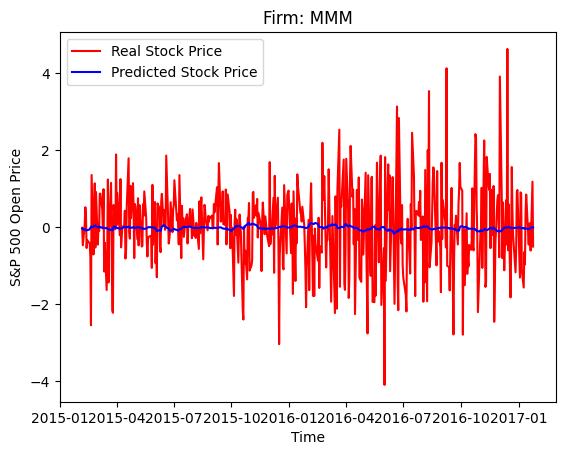

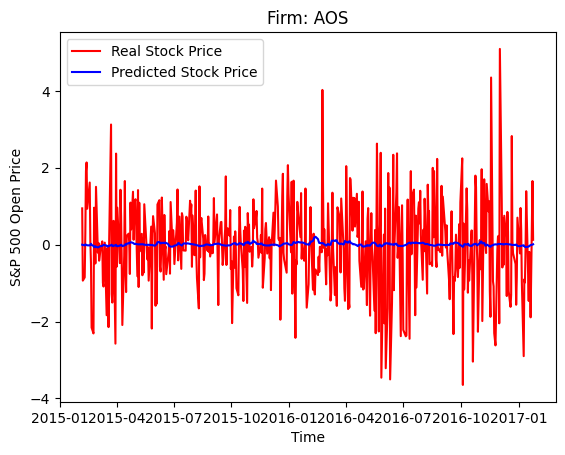

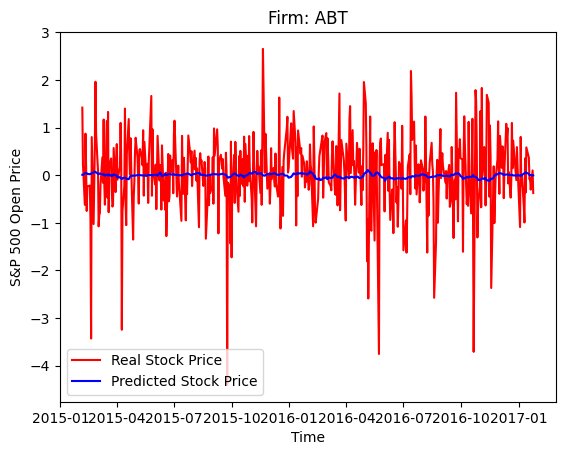

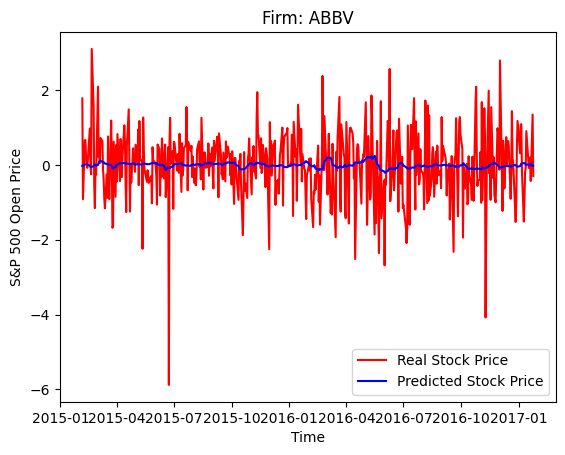

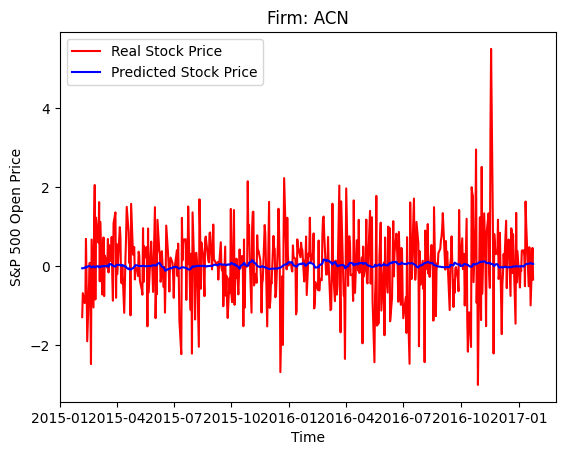

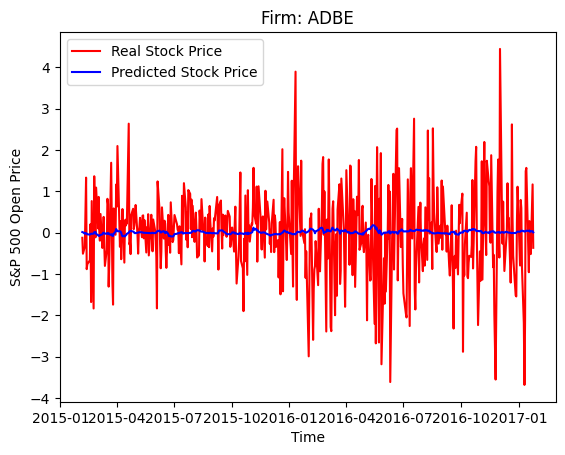

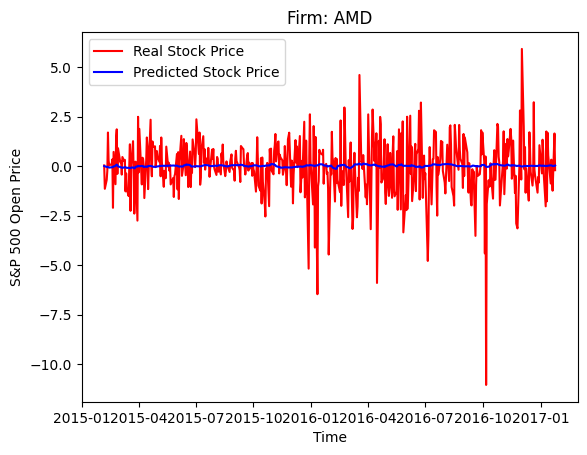

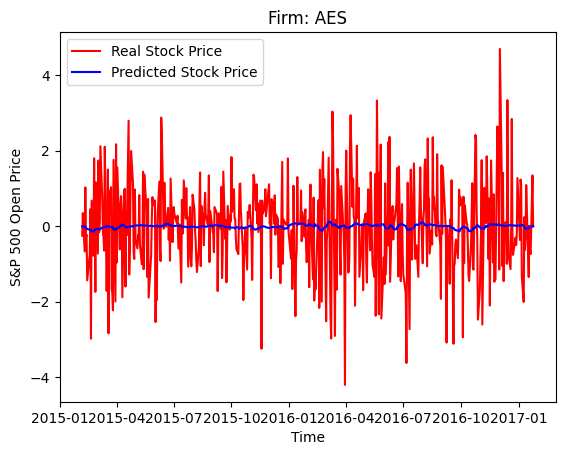

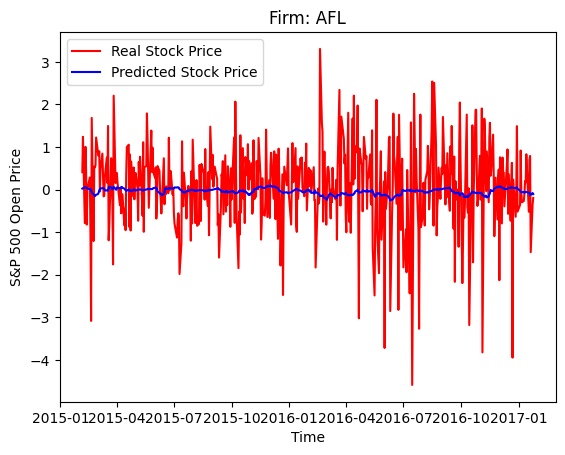

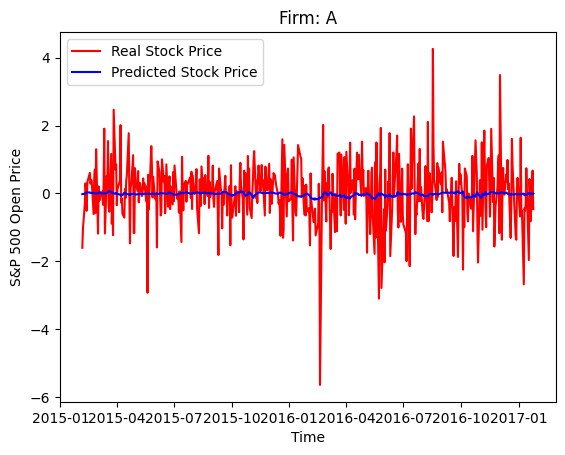

In [51]:
pred_test_TGC = dict_adj_matrices['everything']['pred']
plot_results(y_test, pred_test_TGC)

In [52]:
for key, val in MSE_dict.items():
  print(f'{key}: {np.mean(val)}')

MSE_array_average: 1.5556620359420776
MSE_array_LSTM: 1.5577607154846191
MSE_array_sector: 1.5790677070617676
MSE_array_industry: 1.5833345651626587
MSE_array_corre: 1.5548713207244873
MSE_array_everything: 1.5826064348220825


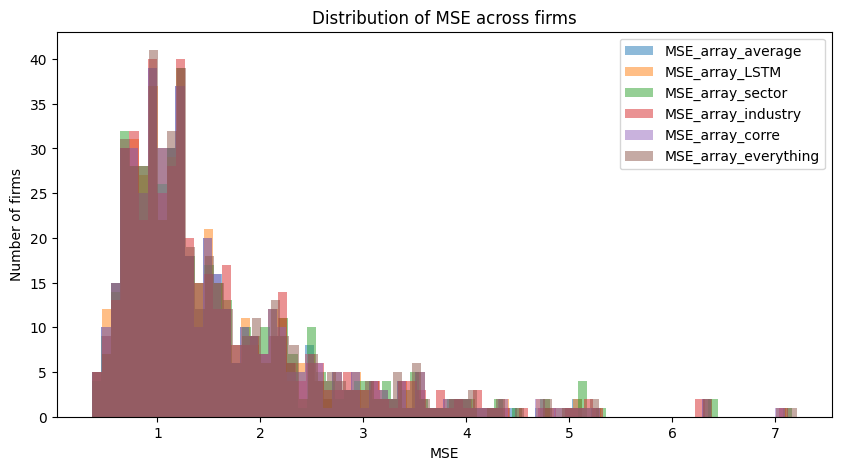

In [53]:
# plot results that compares average, LSTM, and TGC
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for key, val in MSE_dict.items():
  plt.hist(val, bins=75, alpha=0.5, label=f'{key}')

plt.legend()
plt.title("Distribution of MSE across firms")
plt.xlabel("MSE")
plt.ylabel("Number of firms")
plt.show()

/var/folders/zw/q9ynbccn7ps6lh79162xl0j80000gn/T/ipykernel_87026/3062524137.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(val_list, labels=label_list)


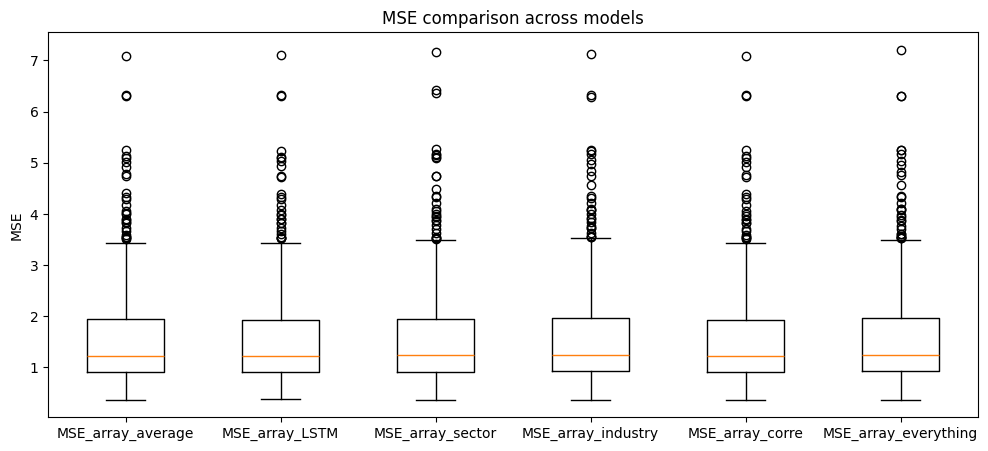

In [54]:
plt.figure(figsize=(12,5))

val_list = []
label_list = []
for key, val in MSE_dict.items():
  val_list.append(val)
  label_list.append(key)

plt.boxplot(val_list, labels=label_list)

plt.title("MSE comparison across models")
plt.ylabel("MSE")
plt.show()

### [new2] ARYAA - using Optuna to finetune hyperparameter of TGC

In [56]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.5 MB/s eta 0:00:001.5 MB/s eta 0:00:01


In [60]:
import optuna
import pandas as pd

optuna.logging.set_verbosity(optuna.logging.WARNING) # silences the spam

def objective(trial, adj_key, metric_name):
    """
    trial:       Optuna gives this automatically — it's how you ask for hyperparameter suggestions
    adj_key:     which graph to use — 'sector', 'industry', 'corre', or 'everything'
    metric_name: which metric to optimise for — 'accuracy', 'f1', 'mcc', 'return_ratio', 'sharpe'
    """

    # Optuna suggests hyperparameter values for this trial
    # Each suggest_ call says: "pick me a value from this range"
    # Optuna gets smarter about which values to pick after each trial

    emb_dim  = trial.suggest_categorical('emb_dim', [16, 32, 64, 128])
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)  # log=True = search on log scale, better for lr
    dropout  = trial.suggest_float('dropout', 0.1, 0.5)
    epochs   = trial.suggest_categorical('epochs', [10, 20, 30])

    # Build the TGC model with those hyperparameters
    A_loop = dict_adj_matrices[adj_key]['matrix']
    K_num_relations = A_loop.shape[-1]

    model = TGCModel(
        num_features  = F,
        emb_dim       = emb_dim,
        gcn_dim       = emb_dim,
        num_relations = K_num_relations
    )

    # Swap the fixed dropout in Header for the trial's dropout value
    # (overrides the hardcoded 0.2 in Nat's Header class)
    for layer in model.head.model:
        if isinstance(layer, nn.Dropout):
            layer.p = dropout

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Train for the chosen number of epochs
    for epoch in range(epochs):
        train_one_epoch(model, train_loader, A_loop, optimizer, criterion)

    # Get predictions on VALIDATION set (not test — never peek at test during tuning)
    val_preds = predict(model, val_loader, A_loop).numpy()  # shape [T_val, N]

    # y_val is the true returns for the validation period
    metrics = compute_metrics(y_val, val_preds)

    # Return the metric Optuna should maximise
    return metrics[metric_name]

## Yagmur


Optimising accuracy on sector graph...
  Best accuracy: 0.5269 | params: {'emb_dim': 16, 'lr': 0.007313006893660627, 'dropout': 0.21265793816095235, 'epochs': 30}

Optimising accuracy on industry graph...
  Best accuracy: 0.5269 | params: {'emb_dim': 64, 'lr': 0.0009579659674824673, 'dropout': 0.26472958148057085, 'epochs': 30}

Optimising accuracy on corre graph...
  Best accuracy: 0.5297 | params: {'emb_dim': 32, 'lr': 0.006344661113671968, 'dropout': 0.20307116993879532, 'epochs': 20}

Optimising accuracy on everything graph...
  Best accuracy: 0.5265 | params: {'emb_dim': 16, 'lr': 0.0025447731007769885, 'dropout': 0.32852459349270763, 'epochs': 10}

Optimising f1 on sector graph...
  Best f1: 0.4694 | params: {'emb_dim': 16, 'lr': 0.000987268067563274, 'dropout': 0.15592561287708323, 'epochs': 20}

Optimising f1 on industry graph...
  Best f1: 0.4465 | params: {'emb_dim': 64, 'lr': 0.0010174024106899828, 'dropout': 0.15750826818752023, 'epochs': 10}

Optimising f1 on corre graph.

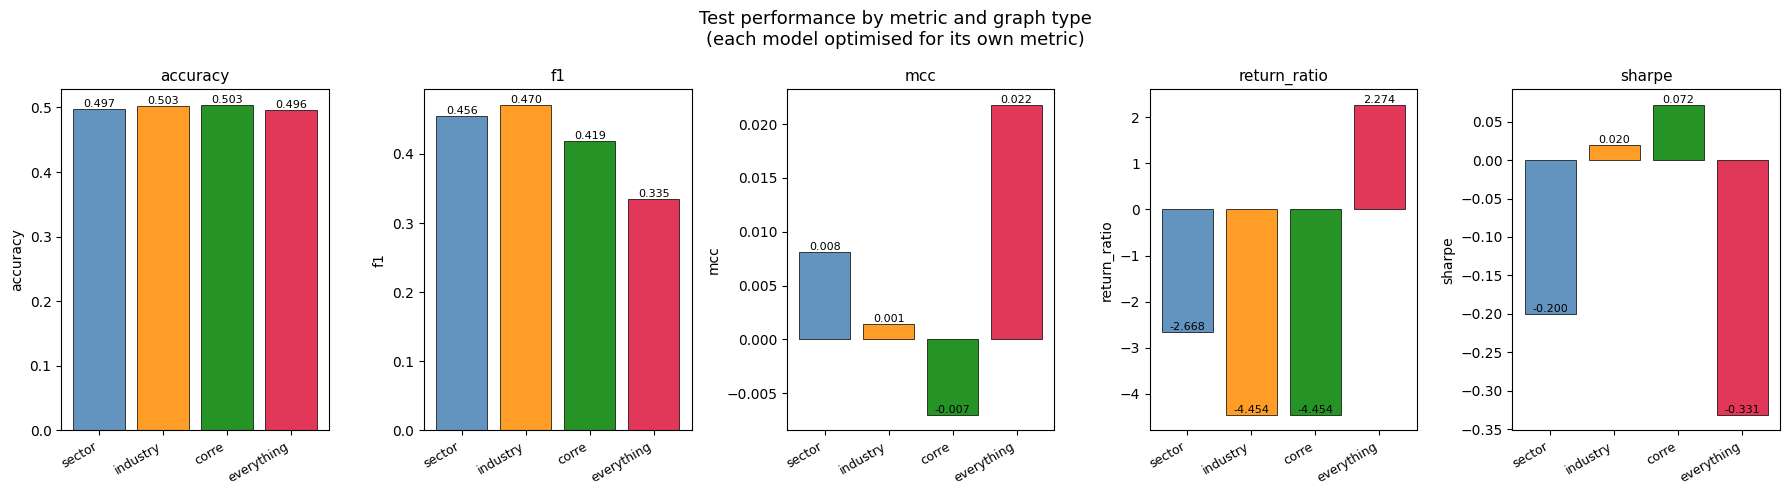

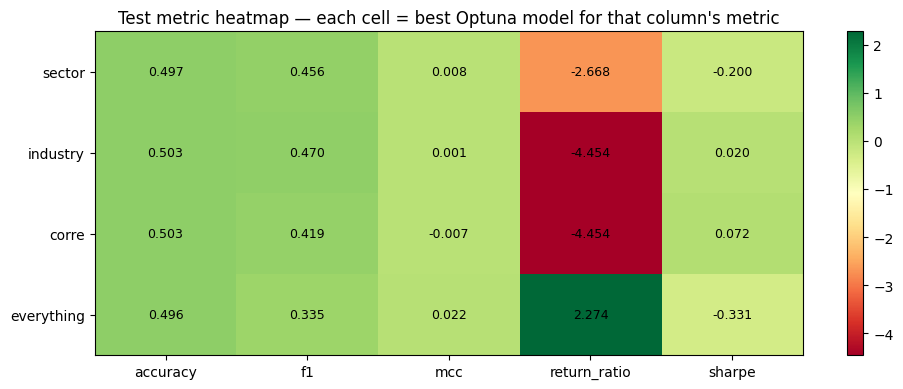

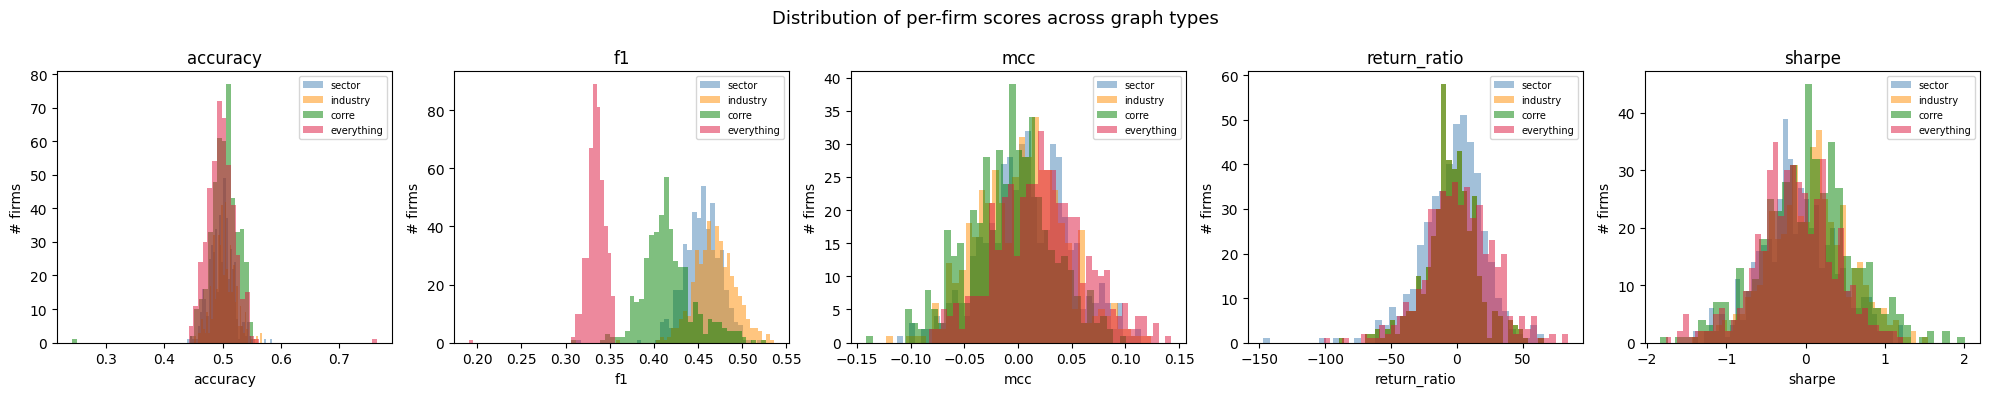

In [61]:
N_TRIALS = 5  # change to 50 for real results

results = {}

for metric_name in ['accuracy', 'f1', 'mcc', 'return_ratio', 'sharpe']:
    results[metric_name] = {}

    for adj_key in ['sector', 'industry', 'corre', 'everything']:
        print(f"\nOptimising {metric_name} on {adj_key} graph...")

        study = optuna.create_study(direction='maximize')
        study.optimize(lambda trial: objective(trial, adj_key, metric_name), n_trials=N_TRIALS)

        results[metric_name][adj_key] = {
            'best_value':  round(study.best_value, 4),
            'best_params': study.best_params
        }
        print(f"  Best {metric_name}: {study.best_value:.4f} | params: {study.best_params}")

# RETRAIN FINAL MODELS
final_models = {}
final_preds  = {}

for metric_name in results:
    final_models[metric_name] = {}
    final_preds[metric_name]  = {}

    for adj_key in ['sector', 'industry', 'corre', 'everything']:
        print(f"\nRetraining best {metric_name} / {adj_key} model...")

        p      = results[metric_name][adj_key]['best_params']
        A_loop = dict_adj_matrices[adj_key]['matrix']
        K_num_relations = A_loop.shape[-1]

        model = TGCModel(
            num_features  = F,
            emb_dim       = p['emb_dim'],
            gcn_dim       = p['emb_dim'],
            num_relations = K_num_relations
        )
        for layer in model.head.model:
            if isinstance(layer, nn.Dropout):
                layer.p = p['dropout']

        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=p['lr'])

        for epoch in range(p['epochs']):
            train_one_epoch(model, train_loader, A_loop, optimizer, criterion)
            train_one_epoch(model, val_loader,   A_loop, optimizer, criterion)

        preds = predict(model, test_loader, A_loop).numpy()
        final_models[metric_name][adj_key] = model
        final_preds[metric_name][adj_key]  = preds
        print(f"  Done. Predictions shape: {preds.shape}")

# EVALUATE ON TEST SET
test_scores = {}

for metric_name in final_preds:
    test_scores[metric_name] = {}
    for adj_key in final_preds[metric_name]:
        preds = final_preds[metric_name][adj_key]
        test_scores[metric_name][adj_key] = compute_metrics(y_test, preds)

# RESULTS TABLE
METRICS     = ['accuracy', 'f1', 'mcc', 'return_ratio', 'sharpe']
GRAPH_TYPES = ['sector', 'industry', 'corre', 'everything']
COLORS      = ['steelblue', 'darkorange', 'green', 'crimson']

print("\n" + "="*70)
print("FINAL TEST RESULTS — best Optuna config per (metric, graph)")
print("="*70)

rows = []
for metric_name in test_scores:
    for adj_key in test_scores[metric_name]:
        row = {'optimised_for': metric_name, 'graph': adj_key}
        row.update(test_scores[metric_name][adj_key])
        rows.append(row)

results_table = pd.DataFrame(rows).set_index(['optimised_for', 'graph'])
print(results_table.to_string())

print("\n--- Best test score per metric (across all graph types) ---")
for metric_name in test_scores:
    best_graph = max(test_scores[metric_name],
                     key=lambda g: test_scores[metric_name][g][metric_name])
    best_val   = test_scores[metric_name][best_graph][metric_name]
    print(f"  {metric_name:15s}: {best_val:.4f}  (graph = {best_graph})")

# PLOTS
fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 5), sharey=False)
fig.suptitle("Test performance by metric and graph type\n(each model optimised for its own metric)", fontsize=13)

for ax, metric_name in zip(axes, METRICS):
    vals = [test_scores[metric_name][g][metric_name] for g in GRAPH_TYPES]
    bars = ax.bar(GRAPH_TYPES, vals, color=COLORS, alpha=0.85, edgecolor='black', linewidth=0.6)
    ax.set_title(metric_name, fontsize=11)
    ax.set_ylabel(metric_name)
    ax.set_xticks(range(len(GRAPH_TYPES)))
    ax.set_xticklabels(GRAPH_TYPES, rotation=30, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

heatmap_data = pd.DataFrame(index=GRAPH_TYPES, columns=METRICS, dtype=float)
for metric_name in METRICS:
    for adj_key in GRAPH_TYPES:
        heatmap_data.loc[adj_key, metric_name] = test_scores[metric_name][adj_key][metric_name]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heatmap_data.values.astype(float), aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(METRICS)));      ax.set_xticklabels(METRICS, fontsize=10)
ax.set_yticks(range(len(GRAPH_TYPES))); ax.set_yticklabels(GRAPH_TYPES, fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title("Test metric heatmap — each cell = best Optuna model for that column's metric")
for i in range(len(GRAPH_TYPES)):
    for j in range(len(METRICS)):
        ax.text(j, i, f"{heatmap_data.values[i, j]:.3f}",
                ha='center', va='center', fontsize=9, color='black')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(METRICS), figsize=(20, 4))
fig.suptitle("Distribution of per-firm scores across graph types", fontsize=13)

for ax, metric_name in zip(axes, METRICS):
    ax.set_title(metric_name)
    for adj_key, color in zip(GRAPH_TYPES, COLORS):
        preds = final_preds[metric_name][adj_key]
        y_dir = (y_test > 0).astype(int)
        p_dir = (preds  > 0).astype(int)
        if metric_name == 'accuracy':
            per_firm = [(y_dir[:, i] == p_dir[:, i]).mean() for i in range(y_test.shape[1])]
        elif metric_name == 'f1':
            from sklearn.metrics import f1_score
            per_firm = [f1_score(y_dir[:, i], p_dir[:, i], average='macro', zero_division=0)
                        for i in range(y_test.shape[1])]
        elif metric_name == 'mcc':
            from sklearn.metrics import matthews_corrcoef
            per_firm = [matthews_corrcoef(y_dir[:, i], p_dir[:, i])
                        for i in range(y_test.shape[1])]
        elif metric_name == 'return_ratio':
            trade    = np.where(p_dir == 1, 1, -1)
            per_firm = (y_test * trade).sum(axis=0).tolist()
        elif metric_name == 'sharpe':
            trade    = np.where(p_dir == 1, 1, -1)
            rets     = y_test * trade
            mu       = rets.mean(axis=0)
            sigma    = rets.std(axis=0) + 1e-8
            per_firm = (mu / sigma * np.sqrt(252)).tolist()

        ax.hist(per_firm, bins=40, alpha=0.5, label=adj_key, color=color)

    ax.legend(fontsize=7)
    ax.set_xlabel(metric_name)
    ax.set_ylabel("# firms")

plt.tight_layout()
plt.show()

In [ ]:
lstm_test_metrics = compute_metrics(y_test, pred_scaled)
print("LSTM baseline metrics:")
for k, v in lstm_test_metrics.items():
    print(f"  {k:15s}: {v:.4f}")